In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Downloads/cibil_score.csv")

In [4]:
print("Shape:", df.shape)

Shape: (51336, 88)


In [5]:
df.head()

,Unnamed: 0,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,0,1,5,4,1,0,0,0.000,0.0,0.200,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,1,2,1,0,1,0,0,0.000,0.0,1.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,2,3,8,0,8,1,0,0.125,0.0,1.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,3,4,1,0,1,1,0,1.000,0.0,1.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,4,5,3,2,1,0,0,0.000,0.0,0.333,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    51336 non-null  int64  
 1   PROSPECTID                    51336 non-null  int64  
 2   Total_TL                      51336 non-null  int64  
 3   Tot_Closed_TL                 51336 non-null  int64  
 4   Tot_Active_TL                 51336 non-null  int64  
 5   Total_TL_opened_L6M           51336 non-null  int64  
 6   Tot_TL_closed_L6M             51336 non-null  int64  
 7   pct_tl_open_L6M               51336 non-null  float64
 8   pct_tl_closed_L6M             51336 non-null  float64
 9   pct_active_tl                 51336 non-null  float64
 10  pct_closed_tl                 51336 non-null  float64
 11  Total_TL_opened_L12M          51336 non-null  int64  
 12  Tot_TL_closed_L12M            51336 non-null  int64  
 13  pct_tl_open_

In [7]:
df.describe()

,Unnamed: 0,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25667.500000,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12833.750000,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25667.500000,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38501.250000,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51335.000000,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


In [8]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [9]:
df = df.drop(columns=["Unnamed: 0"])

# normalize column names
df.columns = [col.lower().strip() for col in df.columns]

print(df.shape)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.head()

(51336, 87)
Duplicate rows: 0


,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,last_prod_enq2,first_prod_enq2,credit_score,approved_flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [ ]:
X = df.drop(
    columns=["credit_score", "approved_flag"],
    errors="ignore" # what errors=ignore
)

y = df["credit_score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
) # what if random state is changed
# How to create validation set?

In [12]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 80
Categorical columns: 5


C:\Users\Kamal\AppData\Local\Temp\ipykernel_22704\3628468883.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # This is not correct for our data
        ("scaler", StandardScaler())
    ]
)

In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), # Why with most_frequent?
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False # what handle_unknown and sparse_output will do
            )
        )
    ]
)

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [17]:
print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 85
Processed features: 103


In [ ]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_processed) # how this is different than fit_predict
X_test_pca = pca.transform(X_test_processed)

In [19]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[1.52720103e-01 1.07077668e-01 7.30859353e-02 5.63366824e-02
 4.30962770e-02 3.59804792e-02 3.24655620e-02 3.16011642e-02
 2.88586519e-02 2.69251748e-02 2.53088562e-02 2.44759105e-02
 2.36509790e-02 2.13999345e-02 2.08071796e-02 1.83821878e-02
 1.75103712e-02 1.69011463e-02 1.66269931e-02 1.59080029e-02
 1.29388353e-02 1.21431662e-02 1.19102467e-02 1.18037481e-02
 1.14341659e-02 1.02190370e-02 9.84902337e-03 9.30836399e-03
 8.52021403e-03 7.85839239e-03 7.12032026e-03 6.93280412e-03
 5.99140500e-03 5.68716369e-03 5.53152618e-03 4.69731846e-03
 4.24268745e-03 4.19027126e-03 4.08528961e-03 3.70115246e-03
 3.61148023e-03 3.52605477e-03 3.20316398e-03 3.08467789e-03
 2.95743196e-03 2.83666640e-03 2.50700821e-03 2.47205005e-03
 2.32220966e-03 1.88048638e-03 1.82489529e-03 1.72088803e-03
 1.56387170e-03 1.53243647e-03 1.49807104e-03 1.42300726e-03
 1.32958884e-03 1.26550582e-03 1.19889323e-03 1.18151486e-03
 1.08923126e-03 8.29755826e-04 8.13067657e-04 7.66098301e-04
 6.71803299e-04 5.996844

In [20]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.1527201  0.25979777 0.33288371 0.38922039 0.43231667 0.46829715
 0.50076271 0.53236387 0.56122252 0.5881477  0.61345655 0.63793246
 0.66158344 0.68298338 0.70379056 0.72217275 0.73968312 0.75658426
 0.77321126 0.78911926 0.80205809 0.81420126 0.82611151 0.83791526
 0.84934942 0.85956846 0.86941748 0.87872585 0.88724606 0.89510445
 0.90222477 0.90915758 0.91514898 0.92083615 0.92636767 0.93106499
 0.93530768 0.93949795 0.94358324 0.94728439 0.95089587 0.95442193
 0.95762509 0.96070977 0.9636672  0.96650387 0.96901087 0.97148292
 0.97380513 0.97568562 0.97751052 0.9792314  0.98079528 0.98232771
 0.98382578 0.98524879 0.98657838 0.98784388 0.98904278 0.99022429
 0.99131352 0.99214328 0.99295635 0.99372245 0.99439425 0.99499393
 0.99555446 0.99609238 0.99662292 0.99710156 0.99757377 0.99802594
 0.99842331 0.998777   0.99911443 0.99943628 0.99974211 0.99992812
 0.99999808 0.99999949 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        

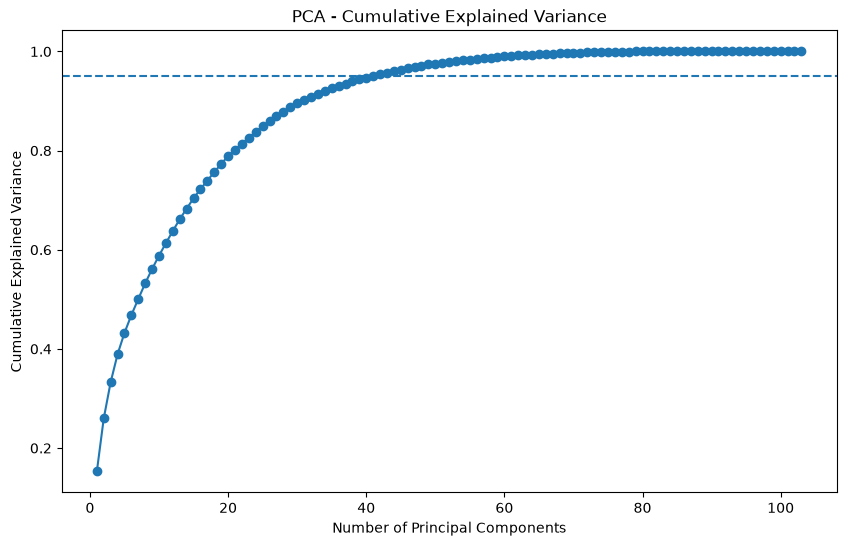

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.show()

In [22]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Number of components required for 95% variance:",
    n_components_95
)

Number of components required for 95% variance: 41


In [23]:
pca_95 = PCA(
    n_components=0.95
)

X_train_pca = pca_95.fit_transform(
    X_train_processed
)

X_test_pca = pca_95.transform(
    X_test_processed
)

In [24]:
print(
    "Original number of features:",
    X_train_processed.shape[1]
)

print(
    "Number of PCA components:",
    X_train_pca.shape[1]
)

Original number of features: 103
Number of PCA components: 41


The original preprocessed dataset contained 103 features. PCA reduced these to 41 principal components while retaining 95% of the total variance. Therefore, PCA achieved dimensionality reduction while preserving most of the information present in the original dataset.

In [25]:
print(
    "Variance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Variance retained: 0.9508958711691496


The 58 components retain approximately 95.08% of the variance.

In [26]:
feature_names = preprocessor.get_feature_names_out()

components_df = pd.DataFrame(
    pca_95.components_,
    columns=feature_names
)

print(components_df.head())

   num__prospectid  num__total_tl  num__tot_closed_tl  num__tot_active_tl  \
0         0.000163       0.081788            0.051545            0.122143   
1         0.000220       0.270489            0.253180            0.190874   
2         0.000512       0.057835           -0.005420            0.194239   
3        -0.000149      -0.098454           -0.140556            0.055220   
4         0.005507      -0.104870           -0.090557           -0.093586   

   num__total_tl_opened_l6m  num__tot_tl_closed_l6m  num__pct_tl_open_l6m  \
0                  0.102523                0.081704              0.049930   
1                  0.115952                0.163433             -0.060860   
2                  0.249734                0.120311              0.211987   
3                  0.014794               -0.125383              0.109094   
4                  0.015317                0.180778             -0.038657   

   num__pct_tl_closed_l6m  num__pct_active_tl  num__pct_closed_tl  ...  \


In [27]:
pc1 = components_df.iloc[0]

print(
    pc1.abs()
    .sort_values(ascending=False)
    .head(10)
)

num__tot_enq        0.260764
num__enq_l12m       0.260759
num__enq_l6m        0.260757
num__pl_enq         0.260756
num__pl_enq_l12m    0.260755
num__cc_enq         0.260755
num__enq_l3m        0.260755
num__pl_enq_l6m     0.260754
num__cc_enq_l12m    0.260754
num__cc_enq_l6m     0.260754
Name: 0, dtype: float64


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

linear_pca = LinearRegression()

linear_pca.fit(
    X_train_pca,
    y_train
)

y_pred = linear_pca.predict(
    X_test_pca
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("PCA Linear Regression")
print("---------------------")
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

PCA Linear Regression
---------------------
R²: 0.560922942068653
MAE: 9.992838839236365
RMSE: 13.552228180027926


PCA was applied to reduce the dimensionality of the CIBIL dataset while retaining 95% of the variance.
The PCA-based Linear Regression model achieved an R² score of 0.561, with an MAE of 9.99 and RMSE of 13.55. 
Compared with the original Linear Regression model, the PCA-based model showed lower predictive performance.
This indicates that although PCA retained most of the variance in the predictors,
some information relevant to predicting credit score was lost during dimensionality reduction. 
Therefore, PCA may not be beneficial for this particular Linear Regression task

In [29]:
# ==========================================
# PCA + LOGISTIC REGRESSION
# Target = approved_flag
# ==========================================

X_log = df.drop(
    columns=["approved_flag", "credit_score"],
    errors="ignore"
)

y_log = df["approved_flag"]

In [30]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log,
    y_log,
    test_size=0.20,
    random_state=42,
    stratify=y_log
)

X_log_train → training features
X_log_test  → testing features

y_log_train → training target
y_log_test  → testing target

In [31]:
log_numeric_cols = X_log_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

log_categorical_cols = X_log_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:", len(log_numeric_cols))
print("Categorical columns:", len(log_categorical_cols))

Numerical columns: 80
Categorical columns: 5


C:\Users\Kamal\AppData\Local\Temp\ipykernel_22704\964667055.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  log_categorical_cols = X_log_train.select_dtypes(


In [32]:
log_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

log_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [33]:
log_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            log_numeric_pipeline,
            log_numeric_cols
        ),
        (
            "cat",
            log_categorical_pipeline,
            log_categorical_cols
        )
    ]
)

In [34]:
X_log_train_processed = log_preprocessor.fit_transform(
    X_log_train
)

X_log_test_processed = log_preprocessor.transform(
    X_log_test
)

print(
    "Processed training shape:",
    X_log_train_processed.shape
)

print(
    "Processed testing shape:",
    X_log_test_processed.shape
)

Processed training shape: (41068, 103)
Processed testing shape: (10268, 103)


In [35]:
pca_log = PCA(
    n_components=0.95
)

X_log_train_pca = pca_log.fit_transform(
    X_log_train_processed
)

X_log_test_pca = pca_log.transform(
    X_log_test_processed
)

print(
    "Original features:",
    X_log_train_processed.shape[1]
)

print(
    "PCA components:",
    X_log_train_pca.shape[1]
)

print(
    "Variance retained:",
    pca_log.explained_variance_ratio_.sum()
)

Original features: 103
PCA components: 41
Variance retained: 0.951223725771805


In [36]:
from sklearn.linear_model import LogisticRegression

PCA reduced the 103 processed features to 41 principal components while retaining approximately 95% of the variance

In [37]:
logistic_pca_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_pca_model.fit(
    X_log_train_pca,
    y_log_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [38]:
y_log_pred_pca = logistic_pca_model.predict(
    X_log_test_pca
)

y_log_prob_pca = logistic_pca_model.predict_proba(
    X_log_test_pca
)[:, 1]

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [40]:
accuracy_log_pca = accuracy_score(
    y_log_test,
    y_log_pred_pca
)

precision_log_pca = precision_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

recall_log_pca = recall_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

f1_log_pca = f1_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

print("PCA + Logistic Regression Results")
print("----------------------------------")
print("Accuracy :", accuracy_log_pca)
print("Precision:", precision_log_pca)
print("Recall   :", recall_log_pca)
print("F1 Score :", f1_log_pca)

PCA + Logistic Regression Results
----------------------------------
Accuracy : 0.6990650564861707
Precision: 0.655345457548133
Recall   : 0.6990650564861707
F1 Score : 0.6418421371280534


We applied PCA before Logistic Regression to reduce the dimensionality of the CIBIL dataset.
PCA transformed the original features into a smaller number of principal components while retaining 95% of the variance.
We then trained a multiclass Logistic Regression model to predict the four approved_flag classes — P1, P2, P3 and P4.
The model achieved 69.91% accuracy, 65.53% weighted precision, 69.91% weighted recall and 64.18% weighted F1 score

In [41]:
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_log_test,
        y_log_pred_pca
    )
)


Confusion Matrix:
[[ 568  586    0    7]
 [ 168 6019   35  218]
 [  23 1124   44  300]
 [   2  598   29  547]]


In [42]:
print("\nClassification Report:")

print(
    classification_report(
        y_log_test,
        y_log_pred_pca,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

          P1       0.75      0.49      0.59      1161
          P2       0.72      0.93      0.82      6440
          P3       0.41      0.03      0.06      1491
          P4       0.51      0.47      0.49      1176

    accuracy                           0.70     10268
   macro avg       0.60      0.48      0.49     10268
weighted avg       0.66      0.70      0.64     10268



We applied PCA as a dimensionality-reduction technique and then used Logistic Regression to predict the approved_flag. 
The model achieved 69.91% accuracy.
The model performs best for P2, 
while P3 has very low recall, indicating that the model has difficulty identifying P3 observations.

In [43]:
# ==========================================
# PCA + MULTICLASS CLASSIFICATION
# Target = approved_flag
# ==========================================

X_multi_pca = df.drop(
    columns=["approved_flag", "credit_score"],
    errors="ignore"
)

y_multi_pca = df["approved_flag"]

In [44]:
from sklearn.model_selection import train_test_split

X_multi_pca_train, X_multi_pca_test, \
y_multi_pca_train, y_multi_pca_test = train_test_split(
    X_multi_pca,
    y_multi_pca,
    test_size=0.20,
    random_state=42,
    stratify=y_multi_pca
)

In [45]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

multi_num_cols = X_multi_pca_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

multi_cat_cols = X_multi_pca_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

C:\Users\Kamal\AppData\Local\Temp\ipykernel_22704\1223051430.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  multi_cat_cols = X_multi_pca_train.select_dtypes(


In [46]:
multi_num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [47]:
multi_cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [48]:
multi_pca_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            multi_num_pipeline,
            multi_num_cols
        ),
        (
            "cat",
            multi_cat_pipeline,
            multi_cat_cols
        )
    ]
)

In [49]:
X_multi_pca_train_processed = (
    multi_pca_preprocessor.fit_transform(
        X_multi_pca_train
    )
)

X_multi_pca_test_processed = (
    multi_pca_preprocessor.transform(
        X_multi_pca_test
    )
)

print(
    "Training shape:",
    X_multi_pca_train_processed.shape
)

print(
    "Testing shape:",
    X_multi_pca_test_processed.shape
)

Training shape: (41068, 103)
Testing shape: (10268, 103)


In [50]:
from sklearn.decomposition import PCA

pca_multi = PCA(
    n_components=0.95
)

X_multi_pca_train_reduced = (
    pca_multi.fit_transform(
        X_multi_pca_train_processed
    )
)

X_multi_pca_test_reduced = (
    pca_multi.transform(
        X_multi_pca_test_processed
    )
)

In [51]:
print(
    "Original number of features:",
    X_multi_pca_train_processed.shape[1]
)

print(
    "Number of PCA components:",
    X_multi_pca_train_reduced.shape[1]
)

print(
    "Variance retained:",
    pca_multi.explained_variance_ratio_.sum()
)

Original number of features: 103
Number of PCA components: 41
Variance retained: 0.951223725771805


In [52]:
from sklearn.linear_model import LogisticRegression

multi_pca_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

multi_pca_model.fit(
    X_multi_pca_train_reduced,
    y_multi_pca_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [53]:
y_multi_pca_pred = multi_pca_model.predict(
    X_multi_pca_test_reduced
)

y_multi_pca_prob = multi_pca_model.predict_proba(
    X_multi_pca_test_reduced
)

In [54]:
from sklearn.metrics import accuracy_score

accuracy_multi_pca = accuracy_score(
    y_multi_pca_test,
    y_multi_pca_pred
)

print("Multiclass + PCA Results")
print("------------------------")
print("Accuracy:", accuracy_multi_pca)

Multiclass + PCA Results
------------------------
Accuracy: 0.6990650564861707


In [55]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

precision_multi_pca = precision_score(
    y_multi_pca_test,
    y_multi_pca_pred,
    average="weighted",
    zero_division=0
)

recall_multi_pca = recall_score(
    y_multi_pca_test,
    y_multi_pca_pred,
    average="weighted",
    zero_division=0
)

f1_multi_pca = f1_score(
    y_multi_pca_test,
    y_multi_pca_pred,
    average="weighted",
    zero_division=0
)

print("Multiclass + PCA Results")
print("------------------------")
print("Accuracy :", accuracy_multi_pca)
print("Precision:", precision_multi_pca)
print("Recall   :", recall_multi_pca)
print("F1 Score :", f1_multi_pca)

Multiclass + PCA Results
------------------------
Accuracy : 0.6990650564861707
Precision: 0.655345457548133
Recall   : 0.6990650564861707
F1 Score : 0.6418421371280534


In [56]:
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_multi_pca_test,
        y_multi_pca_pred,
        labels=["P1", "P2", "P3", "P4"]
    )
)


Confusion Matrix:
[[ 568  586    0    7]
 [ 168 6019   35  218]
 [  23 1124   44  300]
 [   2  598   29  547]]


In [57]:
print("\nClassification Report:")

print(
    classification_report(
        y_multi_pca_test,
        y_multi_pca_pred,
        labels=["P1", "P2", "P3", "P4"],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

          P1       0.75      0.49      0.59      1161
          P2       0.72      0.93      0.82      6440
          P3       0.41      0.03      0.06      1491
          P4       0.51      0.47      0.49      1176

    accuracy                           0.70     10268
   macro avg       0.60      0.48      0.49     10268
weighted avg       0.66      0.70      0.64     10268



PCA was applied to the preprocessed features to reduce dimensionality while retaining 95% of the variance. 
Logistic Regression was then used to classify the four approved_flag categories: P1, P2, P3 and P4. 
The model achieved 69.91% accuracy and a weighted F1-score of 64.18%.
The model performed particularly well for P2, with an F1-score of 0.82, 
but performed poorly for P3, with an F1-score of only 0.06. 
This indicates that PCA + Logistic Regression has difficulty distinguishing the P3 class.